In [ ]:
import requests

url="https://arxiv.org/pdf/2407.07826.pdf"

resps = requests.get(url)
with open("test.pdf", "wb") as f:
    f.write(resps.content)
    print("Done")




In [2]:
import os

def get_file_extension(file_path):
    _, ext = os.path.splitext(file_path)
    return ext[1:] if ext else ""


file_path="C:\\Users\\91978\\Desktop\\Datasmith-ai\\Pi-Labs\\Test_files\\Test_audio_video\\audio_1.wav"
ext=get_file_extension(file_path)
print(ext)


wav


In [23]:
import fitz  # PyMuPDF
import re

def extract_arxiv_id(pdf_path):
    # Regular expression to match arXiv IDs (e.g., arXiv:2301.12345)
    arxiv_pattern = r'arXiv:\d{4}\.\d{4,5}'

    try:
        doc = fitz.open(pdf_path)
        for page in doc:
            text = page.get_text("text")
            match = re.search(arxiv_pattern, text)
            if match:
                return match.group(0)
    except Exception as e:
        print(f"Error reading PDF: {e}")
        return None

    return None

# Example usage
pdf_file_path = r"C:\Users\91978\Desktop\Ref_Reader_backend\encoder_decoder.pdf"
arxiv_id = extract_arxiv_id(pdf_file_path)

if arxiv_id:
    print(f"Found arXiv ID: {arxiv_id}")
else:
    print("No arXiv ID found in the document.")


Found arXiv ID: arXiv:2002.06595


In [1]:
x="arXiv:2002.06595"
x[6:]

'2002.06595'

In [3]:
from qdrant_client import QdrantClient

client=QdrantClient("http://localhost:6333")
client.recreate_collection(
                    collection_name="testCollection",
                    vectors_config={
                        "size": 1536,
                        "distance": "Cosine"
                    }
                )


C:\Users\91978\AppData\Local\Temp\ipykernel_33624\1525800908.py:4: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


True

In [4]:
groq_api="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"

import os

from groq import Groq

client = Groq(
    api_key="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",
)

chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Explain why fast inference is critical for reasoning models",
        }
    ],
    model="gemma2-9b-it",
)

print(chat_completion.choices[0].message.content)

Fast inference is critical for reasoning models for several reasons:

**1. Real-world Applicability:** 

* **Interactive systems:**  Reasoning models are often envisioned for interactive applications like chatbots, virtual assistants, and real-time decision-making systems. Slow inference times would make these systems unusable in real-world scenarios where immediate responses are expected.

* **Embedded systems:** Deploying reasoning models on resource-constrained devices like smartphones, wearables, or IoT sensors requires efficient inference. Fast inference allows these devices to perform reasoning tasks locally, reducing latency and reliance on cloud computing.

**2. Scalability:** 

* **Large-scale deployments:**  When reasoning models are deployed at scale, serving millions of requests simultaneously, even small delays in inference can significantly impact overall performance and resource utilization. Fast inference is essential for handling such large-scale deployments efficientl

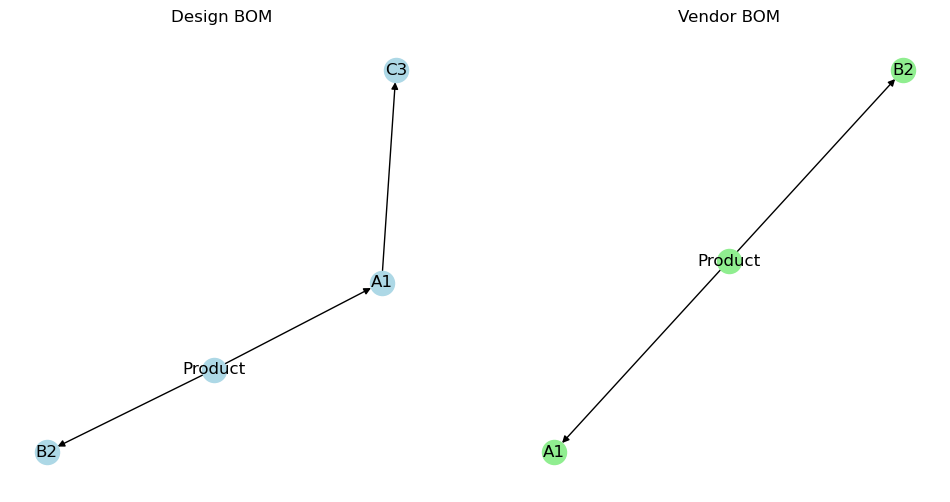

Missing Components: {'C3'}
Missing Dependencies: {('A1', 'C3')}


In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graphs for Design BOM and Vendor BOM
design_BOM = nx.DiGraph()
vendor_BOM = nx.DiGraph()

# Adding nodes and relationships (Example)
design_BOM.add_edges_from([("Product", "A1"), ("Product", "B2"), ("A1", "C3")])
vendor_BOM.add_edges_from([("Product", "A1"), ("Product", "B2")])  # Missing "A1 -> C3"

# Visualizing the BOM structures
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plt.sca(axes[0])  # Set first subplot as active
nx.draw(design_BOM, with_labels=True, node_color='lightblue', ax=axes[0])
axes[0].set_title("Design BOM")

plt.sca(axes[1])  # Set second subplot as active
nx.draw(vendor_BOM, with_labels=True, node_color='lightgreen', ax=axes[1])
axes[1].set_title("Vendor BOM")

plt.show()

# Compare nodes and edges
missing_nodes = set(design_BOM.nodes) - set(vendor_BOM.nodes)
missing_edges = set(design_BOM.edges) - set(vendor_BOM.edges)
print("Missing Components:", missing_nodes)
print("Missing Dependencies:", missing_edges)
